In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib"))

Last updated: 2026-08-14T09:37:09.542588-07:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.6.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.7



In [2]:
code_sim_avg_cpaths = pd.read_csv("code_sim_avg_cpaths.csv")
rev_code_sim_avg_cpaths = pd.read_csv("rev_code_sim_avg_cpaths.csv")
code_sim_avg_cpaths = pd.concat([code_sim_avg_cpaths, rev_code_sim_avg_cpaths], axis=0)

In [3]:
codes = np.unique(code_sim_avg_cpaths.code)

In [4]:
avg_cpath_10bcs = []
for code in codes:
    avg_cpath_10bcs.append(float(code_sim_avg_cpaths.loc[(code_sim_avg_cpaths.code == code) & (code_sim_avg_cpaths.nbarcodes == 10), "ncpaths"]))

C:\Users\jonat\AppData\Local\Temp\ipykernel_24132\3095125906.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  avg_cpath_10bcs.append(float(code_sim_avg_cpaths.loc[(code_sim_avg_cpaths.code == code) & (code_sim_avg_cpaths.nbarcodes == 10), "ncpaths"]))


In [5]:
cd_mx_cpths = pd.DataFrame({"code":codes, "mx_cpaths":avg_cpath_10bcs})
cd_mx_cpths.sort_values('mx_cpaths', ascending=False, inplace=True)


In [6]:
cd_mx_cpths

,code,mx_cpaths
15,seqFISH_q12_n5_k4cb,5450.936
13,seqFISH_intron_2018cb,2778.498
6,RS_q8n9k7w5_10421cws_greedycb,2585.276
0,Hamming_q2_n16_k11_w4cb_MERFISH_2015cb,2439.506
9,RS_q9n9k8w4cb_12903cws_greedycb,811.632
1,MERFISH_2019cb,714.952
5,RS_q8_n9_k6_w5cb,693.672
16,seqFISH_q16_n5_k3cb,322.140
19,seqFISHp2019cb,299.234
3,RS_q13_n10_k6_w6cb,286.044


In [7]:
cd_mx_cpths.code

15                                  seqFISH_q12_n5_k4cb
13                                seqFISH_intron_2018cb
6                         RS_q8n9k7w5_10421cws_greedycb
0                Hamming_q2_n16_k11_w4cb_MERFISH_2015cb
9                       RS_q9n9k8w4cb_12903cws_greedycb
1                                        MERFISH_2019cb
5                                      RS_q8_n9_k6_w5cb
16                                  seqFISH_q16_n5_k3cb
19                                       seqFISHp2019cb
3                                    RS_q13_n10_k6_w6cb
20                         unstructured_100bit_w5_md6cb
14                       seqFISH_n4k3q25_parity_checkcb
18                             seqFISHp2019_used_onlycb
12                                    seqFISHDNA_2020cb
8                         RS_q9n10k8w4cb_3334cws_16hrcb
7                         RS_q9n10k6w5cb_1267cws_16hrcb
4                                    RS_q13_n13_k9_w5cb
2                                    RS_q11_n10_

In [8]:
cd_mx_cpths.code[13]

'seqFISH_intron_2018cb'

In [9]:
code2label = {
    'RS_q8n9k7w5_10421cws_greedycb' : 'Intron seqFISH 2018 RS Match',
    'RS_q9n9k8w4cb_12903cws_greedycb' : 'MERFISH 2019 RS Match',
    'RS_q9n10k8w4cb_3334cws_16hrcb' : 'RNA SeqFISH+ 2019 RS Match',
    'RS_q9n10k6w5cb_1267cws_16hrcb' : 'DNA SeqFISH+ 2020 RS Match',
    'seqFISH_q12_n5_k4cb': "Q-ary Parity Check - q12 n5 k4: 20736 codewords",
    'seqFISH_intron_2018cb': 'Intron seqFISH 2018 Q-ary Parity Check - q12 n5 k4: 10421 codewords',
    'Hamming_q2_n16_k11_w4cb_MERFISH_2015cb': 'Hamming - q2 n16 k11 w4: 140 codewords',
    'MERFISH_2019cb': 'MERFISH 2019 Non-Linear - q2 n69 w4: 12903 codewords',
    'RS_q8_n9_k6_w5cb': 'Reed-Solomon q8 n9 k6 w5: 3528 codewords',
    'seqFISH_q16_n5_k3cb': 'Q-ary Parity Check - q16 n5 k3: 4096 codewords',
    'seqFISHp2019cb': 'Q-ary Parity Check - q20 n4 k3: 8000 codewords',
    'RS_q13_n10_k6_w6cb': 'Reed-Solomon - q13 n10 k6 w6: 20160',
    'unstructured_100bit_w5_md6cb': 'Non-Linear - q2 n100 w5 md6: 12267 codewords', 
    'seqFISH_n4k3q25_parity_checkcb': 'Q-ary Parity Check - q25 n4 k3: 15625 codewords',
    'seqFISHp2019_used_onlycb': 'RNA seqFISH+ Q-ary Parity Check - q20 n4 k3: 3334 codewords',
    'seqFISHDNA_2020cb': 'DNA seqFISH+ 2020 Q-ary Parity Check - q16 n5 k3: 1267 codewords',
    'RS_q13_n13_k9_w5cb': 'Reed-Solomon - q13 n13 k9 w5: 15444 codewords',
    'RS_q11_n10_k7_w4cb': 'Reed-Solomon - q11 n10 k7 w4: 2100 codewords',
    'seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1cb': 'Q-ary Parity Check - q25 n4 k3: 271 codewords',
    'q17n12md5w5cb': 'Reed-Solomon - q17 n12 md5 w5: 12672 codewords',
    'q11_n10_k7_w4cb_pool1cb': 'Reed-Solomon - q11 n10 k7 w4: 271 codewords'
}

In [24]:
dashed = [
'unstructured_100bit_w5_md6cb',
'seqFISH_n4k3q25_parity_checkcb',
'RS_q9n10k6w5cb_1267cws_16hrcb',
'RS_q9n10k8w4cb_3334cws_16hrcb',
'seqFISHp2019_used_onlycb',
'seqFISHDNA_2020cb',
'RS_q13_n13_k9_w5cb',
'RS_q11_n10_k7_w4cb',
'seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1cb',
'q17n12md5w5cb'
]

dotted = ['q11_n10_k7_w4cb_pool1cb']

C:\Users\jonat\AppData\Local\Temp\ipykernel_24132\1981372165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  code_cpaths.sort_values('nbarcodes', inplace=True)


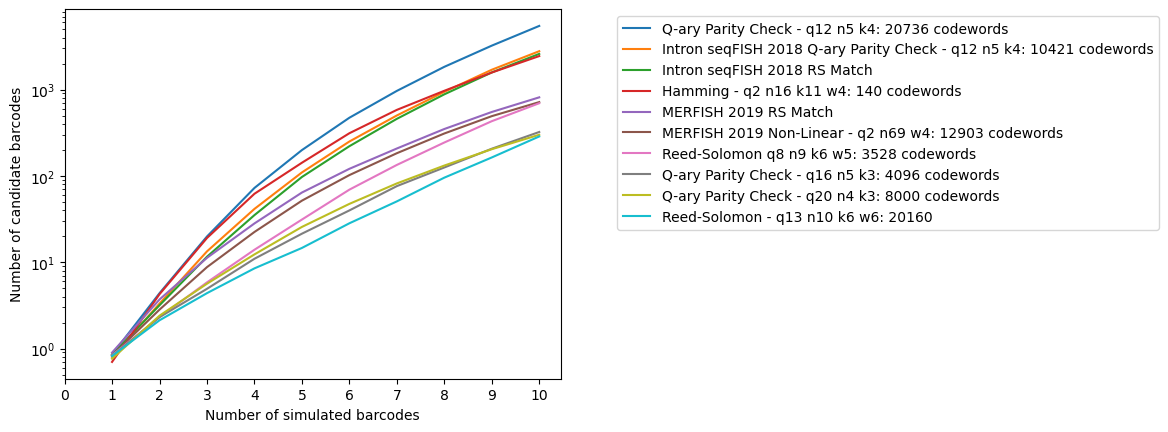

In [25]:
for code in cd_mx_cpths.code:
    code_cpaths = code_sim_avg_cpaths.loc[code_sim_avg_cpaths.code == code]
    #code_cpaths['nbarcodes'] = [int(nbc) for nbc in code_cpaths['nbarcodes']]
    code_cpaths.sort_values('nbarcodes', inplace=True)
    if code in dashed:
        ax.plot(code_cpaths.nbarcodes, code_cpaths.ncpaths, '--',label=code2label[code])
    elif code in dotted:
        ax.plot(code_cpaths.nbarcodes, code_cpaths.ncpaths, ':',label=code2label[code])
    else:
        plt.plot(code_cpaths.nbarcodes, code_cpaths.ncpaths, '-',label=code2label[code])

plt.yscale('log')
plt.xticks(range(11))
plt.legend(bbox_to_anchor=(1.1,1))
plt.xlabel("Number of simulated barcodes")
plt.ylabel("Number of candidate barcodes")
plt.savefig('figS2B.pdf', bbox_inches='tight')

C:\Users\jonat\AppData\Local\Temp\ipykernel_24132\1652361274.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  code_cpaths.sort_values('nbarcodes', inplace=True)


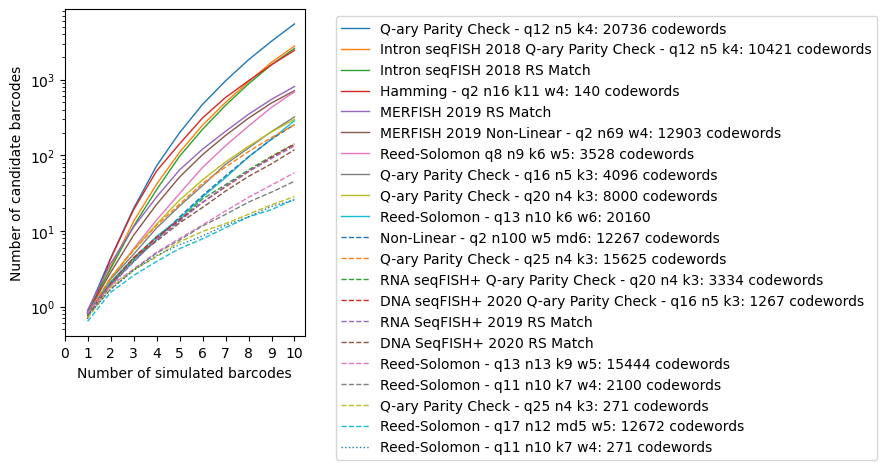

In [32]:
fig, ax = plt.subplots(figsize=(3.1,4.25))
lw = 1
for code in cd_mx_cpths.code:
    code_cpaths = code_sim_avg_cpaths.loc[code_sim_avg_cpaths.code == code]
    #code_cpaths['nbarcodes'] = [int(nbc) for nbc in code_cpaths['nbarcodes']]
    code_cpaths.sort_values('nbarcodes', inplace=True)
    if code in dashed:
        ax.plot(code_cpaths.nbarcodes, code_cpaths.ncpaths, '--',label=code2label[code], linewidth=lw)
    elif code in dotted:
            ax.plot(code_cpaths.nbarcodes, code_cpaths.ncpaths, ':',label=code2label[code], linewidth=lw)
    else:
        ax.plot(code_cpaths.nbarcodes, code_cpaths.ncpaths, '-',label=code2label[code], linewidth=lw)

ax.set_yscale('log')
ax.set_xticks(range(11))
ax.legend(bbox_to_anchor=(1.1,1))
ax.set_xlabel("Number of simulated barcodes")
ax.set_ylabel("Number of candidate barcodes")
plt.savefig('figS2B.pdf', bbox_inches='tight')